In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [ ]:
import pandas as pd

# Load the datasets
android = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/googleplaystore.csv')
ios = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/AppleStore.csv')

# Look at the first few rows to identify column names
print(android.head(3))
print(ios.head(3))

                                                 App        Category  Rating  \
0     Photo Editor & Candy Camera & Grid & ScrapBook  ART_AND_DESIGN     4.1   
1                                Coloring book moana  ART_AND_DESIGN     3.9   
2  U Launcher Lite – FREE Live Cool Themes, Hide ...  ART_AND_DESIGN     4.7   

  Reviews  Size    Installs  Type Price Content Rating  \
0     159   19M     10,000+  Free     0       Everyone   
1     967   14M    500,000+  Free     0       Everyone   
2   87510  8.7M  5,000,000+  Free     0       Everyone   

                      Genres      Last Updated Current Ver   Android Ver  
0               Art & Design   January 7, 2018       1.0.0  4.0.3 and up  
1  Art & Design;Pretend Play  January 15, 2018       2.0.0  4.0.3 and up  
2               Art & Design    August 1, 2018       1.2.4  4.0.3 and up  
   Unnamed: 0         id                                       track_name  \
0           1  281656475                                  PAC-MAN Pre

In [ ]:
# Deleting the known error row in Google Play dataset
print(android.iloc[10472]) # Check the row first
android.drop(10472, inplace=True)

App               Life Made WI-Fi Touchscreen Photo Frame
Category                                              1.9
Rating                                               19.0
Reviews                                              3.0M
Size                                               1,000+
Installs                                             Free
Type                                                    0
Price                                            Everyone
Content Rating                                        NaN
Genres                                  February 11, 2018
Last Updated                                       1.0.19
Current Ver                                    4.0 and up
Android Ver                                           NaN
Name: 10472, dtype: object


In [ ]:
# Create a dictionary to store the max reviews for each app
reviews_max = {}
for index, row in android.iterrows():
    name = row['App']
    n_reviews = float(row['Reviews'])
    if name in reviews_max and reviews_max[name] < n_reviews:
        reviews_max[name] = n_reviews
    elif name not in reviews_max:
        reviews_max[name] = n_reviews

# Use that dictionary to filter the main dataframe
android_clean = android[android.apply(lambda x: reviews_max[x['App']] == float(x['Reviews']), axis=1)]
android_clean = android_clean.drop_duplicates(subset=['App'])

In [ ]:
#removing non english apps
def is_english(string):
    non_ascii = 0
    for character in string:
        if ord(character) > 127:
            non_ascii += 1
    # We allow up to 3 non-ASCII characters (like emojis) before flagging
    return non_ascii <= 3

android_english = android_clean[android_clean['App'].apply(is_english)]

In [ ]:
#isolating free apps
android_final = android_english[android_english['Type'] == 'Free']

In [ ]:
# converting installs to numbers
android_final['Installs'] = android_final['Installs'].str.replace('+', '').str.replace(',', '').astype(float)

/tmp/ipykernel_4470/2290401717.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  android_final['Installs'] = android_final['Installs'].str.replace('+', '').str.replace(',', '').astype(float)


In [ ]:
# Group by Category and find the mean of Installs
category_analysis = android_final.groupby('Category')['Installs'].mean().sort_values(ascending=False)

print(category_analysis.head(10))

Category
COMMUNICATION         3.845612e+07
VIDEO_PLAYERS         2.472787e+07
SOCIAL                2.325365e+07
PHOTOGRAPHY           1.784011e+07
PRODUCTIVITY          1.678733e+07
GAME                  1.558802e+07
TRAVEL_AND_LOCAL      1.398408e+07
ENTERTAINMENT         1.164071e+07
TOOLS                 1.080139e+07
NEWS_AND_MAGAZINES    9.549178e+06
Name: Installs, dtype: float64


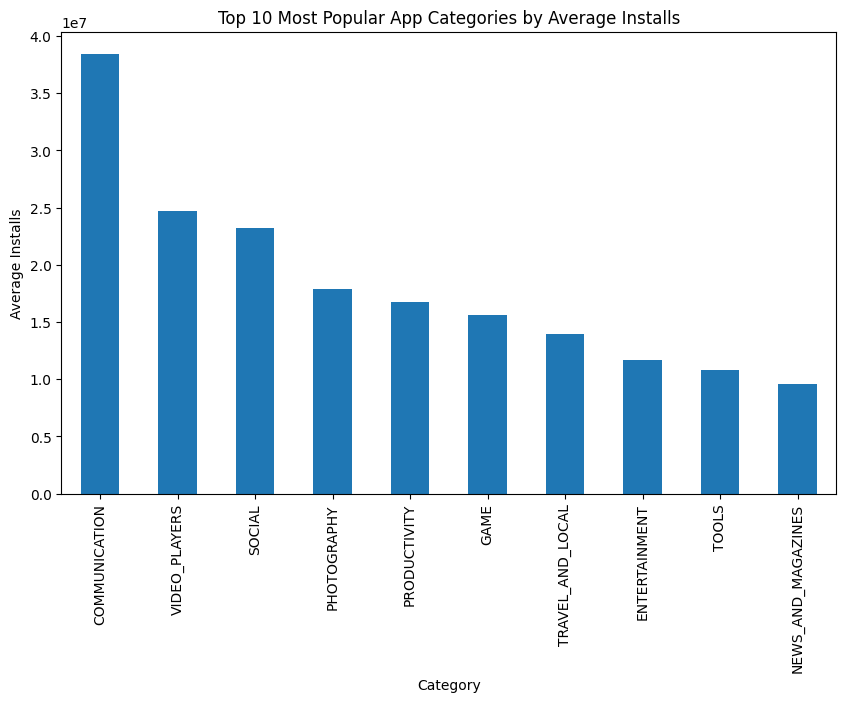

In [ ]:
#VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
category_analysis.head(10).plot.bar()
plt.title('Top 10 Most Popular App Categories by Average Installs')
plt.ylabel('Average Installs')
plt.show()

In [ ]:
android_final.to_csv('cleaned_app_data.csv', index=False)

While Communication apps have the most installs, they are dominated by giants (WhatsApp/Messenger). However, the Communication genre shows high installs with fewer dominant players, making it a better entry point.